In [44]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt

# ============================================================
# 1) LOAD DATA
# ============================================================
df = pd.read_csv('/content/drive/MyDrive/ssh_bruteforce_dataset_complet.csv')
print("Before augmentation:", df.shape)

# ============================================================
# 2) DATA AUGMENTATION (+700 ROWS)
# ============================================================
def augment_data(df, n=700):
    new_rows = []

    for i in range(n):
        row = df.sample(1).iloc[0].copy()

        # Randomize numeric values
        row['failed_attempts'] += np.random.randint(-2, 10)
        row['num_target_servers'] += np.random.randint(0, 3)
        row['num_source_ports'] += np.random.randint(0, 5)
        row['ssh_client_diversity'] += np.random.randint(0, 2)
        row['avg_time_between_attempts'] *= np.random.uniform(0.7, 1.3)
        row['time_variance'] *= np.random.uniform(0.7, 1.3)
        row['total_duration_minutes'] *= np.random.uniform(0.7, 1.2)
        row['attempts_per_minute'] *= np.random.uniform(0.7, 1.2)
        row['port_entropy'] *= np.random.uniform(0.8, 1.2)
        row['target_entropy'] *= np.random.uniform(0.8, 1.2)

        # Adjust timestamps
        row['first_seen'] = pd.to_datetime(row['first_seen']) + pd.Timedelta(minutes=np.random.randint(1, 5000))
        row['last_seen'] = row['first_seen'] + pd.Timedelta(minutes=np.random.randint(1, 60))

        row['is_attack'] = np.random.choice([0, 1], p=[0.5, 0.5])
        new_rows.append(row)

    return pd.concat([df, pd.DataFrame(new_rows)], ignore_index=True)

df = augment_data(df, 700)
print("After augmentation:", df.shape)




Before augmentation: (100, 15)
After augmentation: (800, 15)


In [46]:
# ============================================================
# 3) FEATURE ENGINEERING
# ============================================================

# Convert timestamps
df['first_seen'] = pd.to_datetime(df['first_seen'])
df['last_seen'] = pd.to_datetime(df['last_seen'])

# Session duration
df['session_duration'] = (df['last_seen'] - df['first_seen']).dt.total_seconds()

# Failures per IP
df['failures_per_ip'] = df.groupby('ip_address')['failed_attempts'].transform('sum')

# Attempts frequency
df['attempts_frequency'] = df['failed_attempts'] / (df['session_duration'] + 1)

# Fail2Ban logic
FAIL2BAN_THRESHOLD = 5
df['fail2ban_triggered'] = (df['attempts_frequency'] > FAIL2BAN_THRESHOLD).astype(int)

# Night & Weekend
df['peak_hour'] = df['peak_hour'].astype(int)
df['is_night'] = df['peak_hour'].apply(lambda h: 1 if 0 <= h <= 6 else 0)
df['day_of_week'] = df['first_seen'].dt.dayofweek
df['is_weekend'] = df['day_of_week'].apply(lambda d: 1 if d >= 5 else 0)

# Speed category
df['speed_category'] = pd.cut(
    df['attempts_frequency'],
    bins=[-1, 0.1, 1, 5, 20, np.inf],
    labels=['very_slow', 'slow', 'normal', 'fast', 'extreme']
)
df['speed_category'] = df['speed_category'].astype('category')
df['speed_category_code'] = df['speed_category'].cat.codes

# Port and target behavior
df['port_variability'] = df['num_source_ports'] * df['port_entropy']
df['target_diversity_ratio'] = df['num_target_servers'] * df['target_entropy']
df['attempts_efficiency'] = df['failed_attempts'] / (df['num_source_ports'] + 1)
df['global_entropy'] = df['port_entropy'] + df['target_entropy']


In [47]:
# ============================================================
# 5) SCALING
# ============================================================
features_to_scale = [
    'failed_attempts','num_target_servers','num_source_ports',
    'ssh_client_diversity','avg_time_between_attempts','time_variance',
    'total_duration_minutes','attempts_per_minute','port_entropy','target_entropy',
    'session_duration','failures_per_ip','attempts_frequency','port_variability',
    'target_diversity_ratio','attempts_efficiency','global_entropy'
]

scaler = StandardScaler()
df_scaled = scaler.fit_transform(df[features_to_scale])
df_scaled = pd.DataFrame(df_scaled, columns=features_to_scale)



In [48]:
# ============================================================
# 6) FINAL TRAINING DATA
# ============================================================
X = pd.concat([
    df_scaled,
    df[['is_night', 'is_weekend', 'fail2ban_triggered', 'speed_category_code']]
], axis=1)
y = df['is_attack']

print("\n✔ Final X shape:", X.shape)
print("✔ y shape:", y.shape)
print("\n✔ Features ready for Machine Learning:\n", X.columns.tolist())




✔ Final X shape: (800, 21)
✔ y shape: (800,)

✔ Features ready for Machine Learning:
 ['failed_attempts', 'num_target_servers', 'num_source_ports', 'ssh_client_diversity', 'avg_time_between_attempts', 'time_variance', 'total_duration_minutes', 'attempts_per_minute', 'port_entropy', 'target_entropy', 'session_duration', 'failures_per_ip', 'attempts_frequency', 'port_variability', 'target_diversity_ratio', 'attempts_efficiency', 'global_entropy', 'is_night', 'is_weekend', 'fail2ban_triggered', 'speed_category_code']



Top 10 Features:
                       feature  importance
10           session_duration    0.124552
12         attempts_frequency    0.098855
4   avg_time_between_attempts    0.089970
6      total_duration_minutes    0.089239
5               time_variance    0.083471
15        attempts_efficiency    0.082995
7         attempts_per_minute    0.072275
0             failed_attempts    0.062523
11            failures_per_ip    0.060778
2            num_source_ports    0.056763


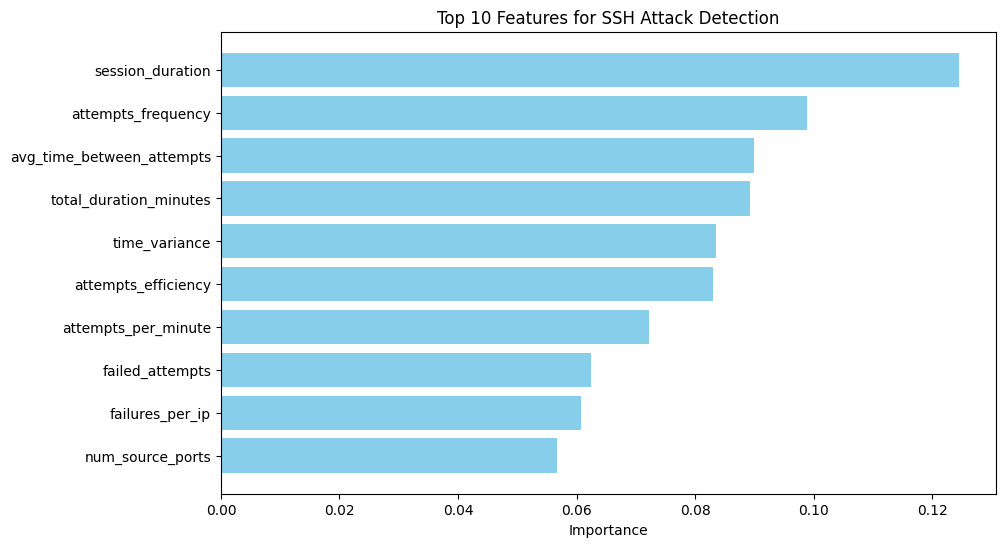

In [49]:
# ============================================================
# 7) TRAIN RANDOM FOREST
# ============================================================
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X, y)

# Feature importances
importances = rf.feature_importances_
feature_names = X.columns
feat_imp_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values(by='importance', ascending=False)

# Show top 10
top10 = feat_imp_df.head(10)
print("\nTop 10 Features:\n", top10)

# Plot
plt.figure(figsize=(10,6))
plt.barh(top10['feature'][::-1], top10['importance'][::-1], color='skyblue')
plt.xlabel('Importance')
plt.title('Top 10 Features for SSH Attack Detection')
plt.show()

In [50]:
# ============================================================
# 8) SAVE DATASET READY FOR ML
# ============================================================
X['is_attack'] = y
output_file = '/content/ssh_dataset_ready_for_ML.csv'
X.to_csv(output_file, index=False)
print(f"\n✔ Dataset saved to {output_file}")

from google.colab import files
files.download(output_file)


✔ Dataset saved to /content/ssh_dataset_ready_for_ML.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [51]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [52]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)


RandomForestClassifier(random_state=42)